# Analyse DX Cluster VHF data

## Software prerequisites and data ingestion

In [1]:
import pandas as pd
import glob

In [2]:
filelist = glob.glob('../dx_cluster/*.xml')

In [3]:
df_list=[]
for individual_file in filelist:
    filename=individual_file.split('/')[-1]
    if (filename[0:3]=='vhf'):
        #print(filename)
        df_list.append(pd.read_xml(individual_file,parse_dates=[1]))
print('files imported')

files imported


In [4]:
concat_df=pd.concat(df_list).drop_duplicates()

In [5]:
concat_df.shape

(200989, 7)

In [6]:
concat_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200989 entries, 0 to 385
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         200989 non-null  object        
 1   time       200989 non-null  datetime64[ns]
 2   spotter    200989 non-null  object        
 3   dx         200989 non-null  object        
 4   frequency  200989 non-null  float64       
 5   comment    186969 non-null  object        
 6   dxcc       200989 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.3+ MB


In [7]:
concat_df

,id,time,spotter,dx,frequency,comment,dxcc
0,7cfb4001cbecc61315755c59c3bfb8dbf5955fe7,2019-01-12 09:46:00,F6HTJ,IS0GRB,144180.0,jm49oj<tr>jn12 opera -17db,225
1,1f0eafe2a46f0330d2a57483101e04817f9ee13e,2019-01-12 09:43:00,F8ZW,OH3MHA,50280.0,jn38sp<ms>kp20xw rx cq cq-gl,224
2,01712aa4c0ad15f498300abd19eafbf648c426a0,2019-01-12 09:39:00,F8ZW,OH3NE,50280.0,jn38sp<ms>kp11ul rx you +11,224
3,e85a3dd4f08e7d484842c26e615fc6ac58f20c7f,2019-01-12 09:39:00,HA9AL,IW1AZJ,50280.0,cq msk144 -02db,248
4,4876187ca01828a96583e9ac5c6569895dfdda52,2019-01-12 09:35:00,HA9AL,DL5RDQ,50280.0,cq msk144 0db,230
...,...,...,...,...,...,...,...
381,a217a34a38db75ee3d182e6c97a7839863f9929b,2019-04-26 09:52:00,HA9AL,IT9EUT,50313.0,ft8 -09db,248
382,cc74f1004c66c96f81cb068fa8cab00f4309954c,2019-04-26 09:52:00,F5JRY,F5JRX,50110.0,cq from jn26,227
383,b7373699461e3f9fc55cbdd1205f85b62bfdaf64,2019-04-26 09:52:00,YO6DDF,IS0GQX,50097.0,cq hrd 5nn here,225
384,67abe4d53c51d92cc9da8e69fa19027a149cdcde,2019-04-26 09:51:00,SV7GBR,OE3XAC/B,50066.0,kn20ix<es>jn78sb; 539,206


## Timeseries analysis

<AxesSubplot: xlabel='time'>

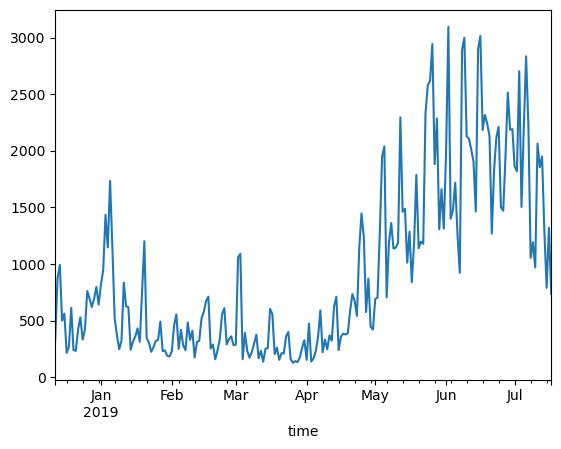

In [8]:
(concat_df
 .set_index('time')
 .sort_index()
 .resample('1D')
 .count()
 ['dx']
 .plot()
)

Better propagation in the summer, or more time for hobbies. Or my deduplication is wrong.

<AxesSubplot: xlabel='time'>

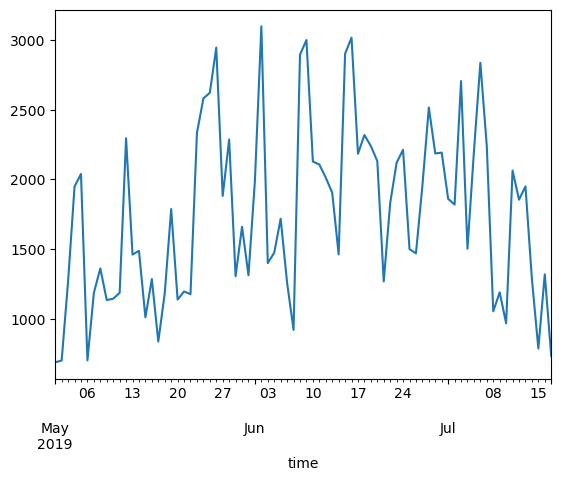

In [9]:
(concat_df
 .set_index('time')
 .sort_index()
 .resample('1D')
 .count()
 ['dx']
 .loc['2019-05':]
 .plot()
)

peaks at weekends?

<AxesSubplot: xlabel='Lag', ylabel='Autocorrelation'>

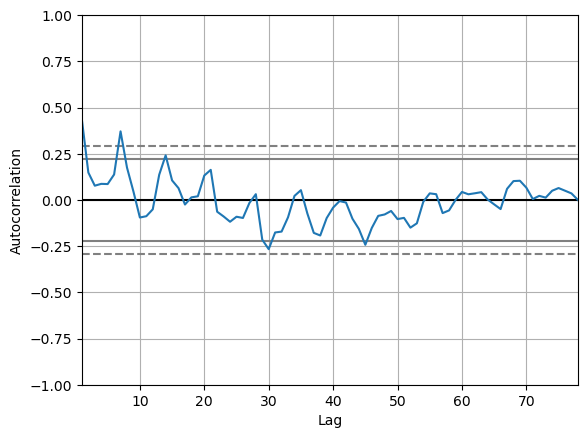

In [10]:
pd.plotting.autocorrelation_plot(concat_df
 .set_index('time')
 .sort_index()
 .resample('1D')
 .count()
 ['dx']
 .loc['2019-05':]
)

7D, 14D, 21D etc.

<AxesSubplot: xlabel='day_no,day_name'>

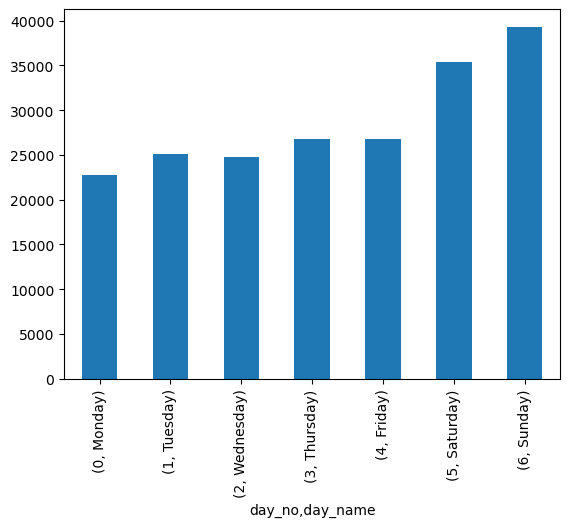

In [11]:
(concat_df
 .assign(day_name=concat_df.time.dt.day_name(),
        day_no=concat_df.time.dt.weekday)
 .groupby(['day_no','day_name'])
 .count()
 #.sort_index()
 .spotter
 .plot(kind='bar')
)

## Spectrum analysis

<AxesSubplot: xlabel='frequency'>

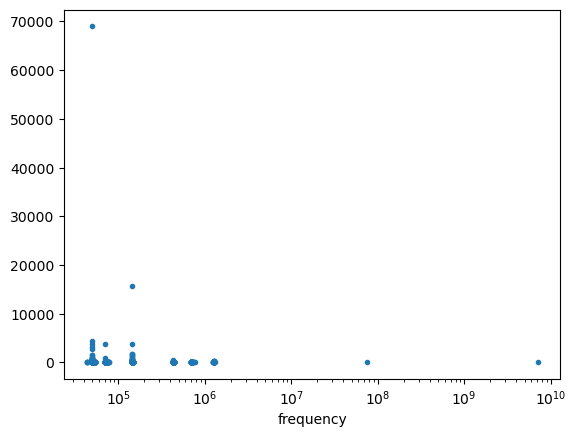

In [12]:
(concat_df
 .groupby('frequency')
 .count()
 .spotter
 .sort_index()
 .plot(logx=True,ls='',marker='.')
)

<AxesSubplot: xlabel='frequency'>

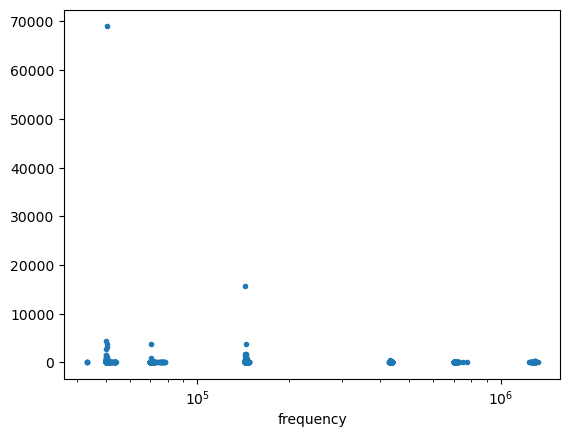

In [13]:
(concat_df
 .groupby('frequency')
 .count()
 .spotter
 .sort_index()
 .loc[:10e6]
 .plot(logx=True,ls='',marker='.')
)

<AxesSubplot: xlabel='freq_MHz'>

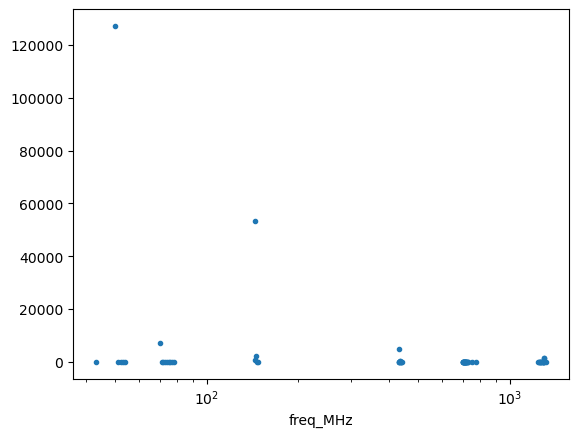

In [14]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .groupby('freq_MHz')
 .count()
 .spotter
 .sort_index()
 .loc[:10e3]
 .plot(logx=True,ls='',marker='.')
)

In [15]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .groupby('freq_MHz')
 .count()
 .spotter
 .sort_index()
 .loc[:10e3]
 .sort_values(ascending=False)
)

freq_MHz
50.0      127035
144.0      53396
70.0        7175
432.0       5088
146.0       2456
           ...  
731.0          1
730.0          1
723.0          1
710.0          1
1323.0         1
Name: spotter, Length: 74, dtype: int64

<AxesSubplot: xlabel='time'>

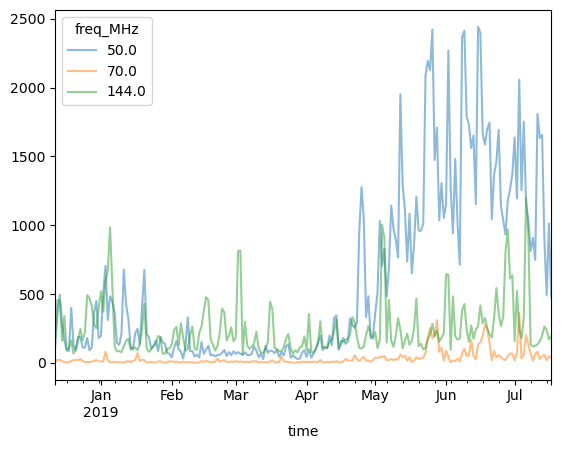

In [16]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .groupby(['time','freq_MHz'])
 .count()
 .spotter
 .unstack()
 [[50.0,70.0,144.0]]
 .resample('1D')
 .sum()
 .plot(alpha=0.5)
)


144 is always a local frequency, but 50 MHz and to a lesser extent 70 MHz become DX frequencies in the summer?

## Propagation analysis

In [17]:
concat_df.spotter.nunique()

9547

In [18]:
concat_df.dx.nunique()

26567

In [19]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .query('freq_MHz==50')
 .set_index('time')
 .sort_index()
 .loc['2019-04-21':]
 .dx
 .nunique()
)

15348

In [20]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .query('freq_MHz==50')
 .set_index('time')
 .sort_index()
 .loc[:'2019-04-20']
 .dx
 .nunique()
)

4429

In [21]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .query('freq_MHz==70')
 .set_index('time')
 .sort_index()
 .loc['2019-04-21':]
 .dx
 .nunique()
)

990

In [22]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .query('freq_MHz==70')
 .set_index('time')
 .sort_index()
 .loc[:'2019-04-20']
 .dx
 .nunique()
)

395

In [23]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .query('freq_MHz==144')
 .set_index('time')
 .sort_index()
 .loc['2019-04-21':]
 .dx
 .nunique()
)

5355

In [24]:
(concat_df
 .assign(freq_MHz=concat_df.frequency.div(1000).round())
 .query('freq_MHz==144')
 .set_index('time')
 .sort_index()
 .loc[:'2019-04-20']
 .dx
 .nunique()
)

5169

Yes!

## Modulation analysis

In [25]:
(concat_df
 .assign(comment_array= concat_df.comment.str.split())
 .explode('comment_array')
 .groupby('comment_array')
 .count()
 .spotter
 .sort_values(ascending=False)
)

comment_array
ft8                 53946
tnx                 31367
cq                  26139
db                  18941
qso                 14367
                    ...  
fn74iu<es>fm17lt        1
fn74iu<es>fm18ke        1
fn74iu<es>fn20dg        1
fn74iu<es>fn32ux        1
ôí÷                     1
Name: spotter, Length: 88247, dtype: int64

<AxesSubplot: ylabel='comment_array'>

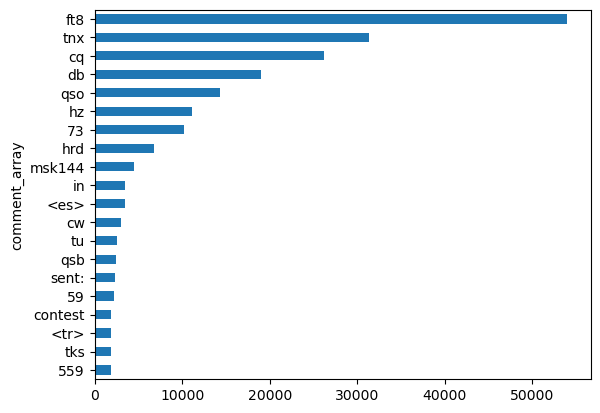

In [26]:
(concat_df
 .assign(comment_array= concat_df.comment.str.split())
 .explode('comment_array')
 .groupby('comment_array')
 .count()
 .spotter
 .sort_values(ascending=False)
 .iloc[0:20]
 .sort_values()
 .plot(kind='barh')
)

In [27]:
def waterfall_freq(df,range_str):
    (df
    .assign(mode= df.comment.str.split())
    .explode('mode')
    .query('mode in ("ft8","cq","msk144","cw","contest") and '+range_str)#frequency > 48_000 and frequency< 50_600
    .groupby(['time','frequency','mode'])
    .count()
    .spotter
    .reset_index()
    .drop(columns='spotter')
    .groupby(['time','mode'])
    .max()
    .frequency
    .unstack()
    .plot(ls='',marker='.',alpha=0.5,ylabel='Freq (khz)')
    .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
    )

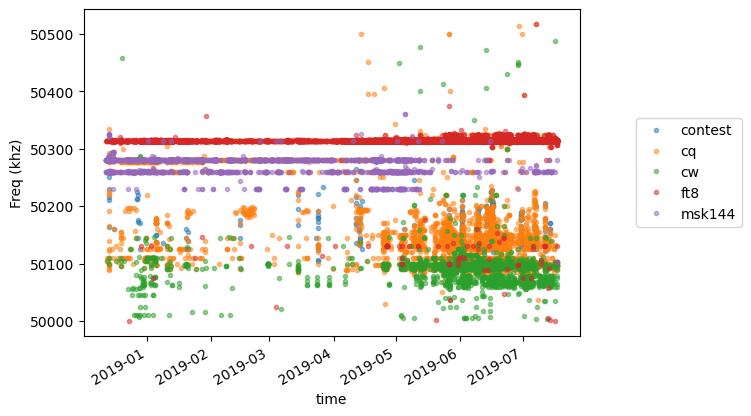

In [28]:
waterfall_freq(concat_df,'frequency > 48_000 and frequency< 50_600')


50 MHz summer DXing: less MSK 144, more ft8, more voice/cq and morse/cw

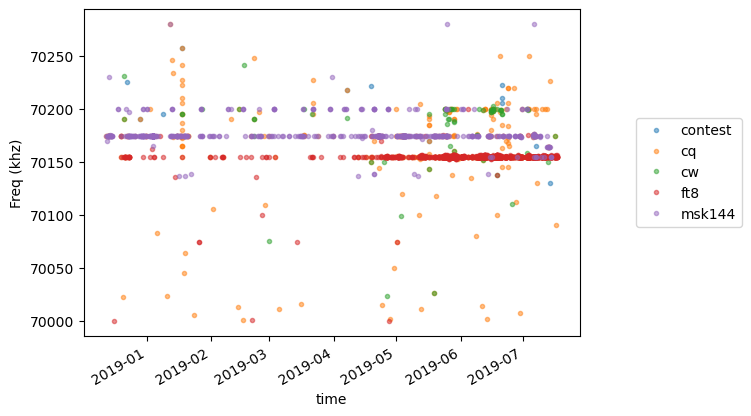

In [29]:
waterfall_freq(concat_df,'frequency > 68_000 and frequency< 70_300')

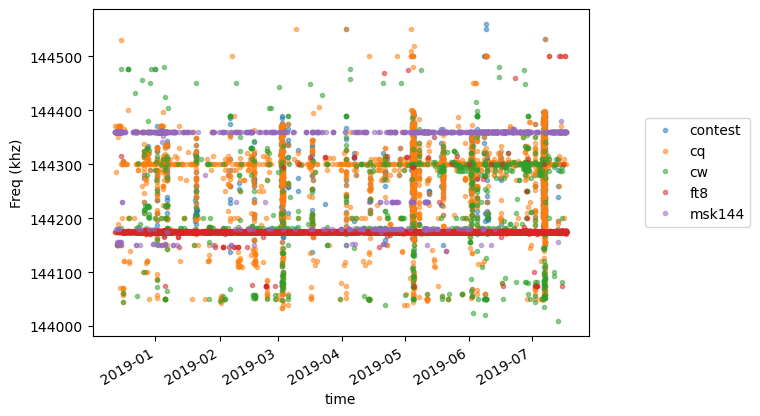

In [30]:
waterfall_freq(concat_df,'frequency > 142_000 and frequency< 144_750')

Vertical lines are bank holidays, but not contests?

<AxesSubplot: xlabel='time'>

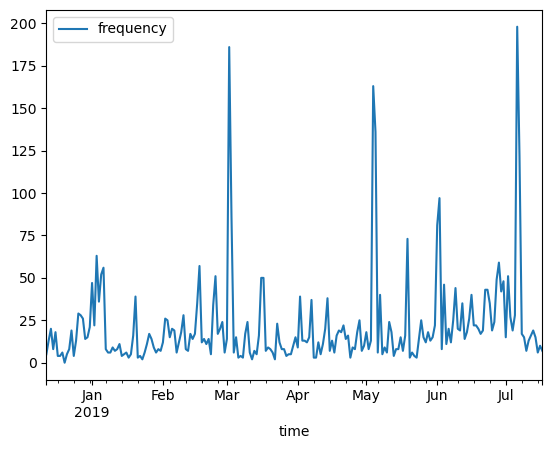

In [31]:
(concat_df
 .assign(comment_array= concat_df.comment.str.split())
 .explode('comment_array')
 .query('comment_array=="cq" and frequency > 142_000 and frequency< 144_750')
 .groupby(['time','frequency'])
 .count()
 .spotter
 .reset_index()
 .drop(columns='spotter')
 .groupby('time')
 .max()
 .resample('1D')
 .count()
 .plot()
)

In [32]:
(concat_df
 .assign(comment_array= concat_df.comment.str.split())
 .explode('comment_array')
 .query('comment_array=="cq" and frequency > 142_000 and frequency< 144_750')
 .groupby(['time','frequency'])
 .count()
 .spotter
 .reset_index()
 .drop(columns='spotter')
 .groupby('time')
 .max()
 .resample('1D')
 .count()
 .sort_values('frequency',ascending=False)
 .iloc[0:10]
)

,frequency
time,
2019-07-06,198
2019-03-02,186
2019-05-04,163
2019-05-05,136
2019-07-07,122
2019-06-02,97
2019-03-03,86
2019-06-01,81
2019-05-19,73


## Power Analysis

In [34]:
concat_df[ concat_df.comment.str.contains("db").fillna(False)]


,id,time,spotter,dx,frequency,comment,dxcc
0,7cfb4001cbecc61315755c59c3bfb8dbf5955fe7,2019-01-12 09:46:00,F6HTJ,IS0GRB,144180.0,jm49oj<tr>jn12 opera -17db,225
3,e85a3dd4f08e7d484842c26e615fc6ac58f20c7f,2019-01-12 09:39:00,HA9AL,IW1AZJ,50280.0,cq msk144 -02db,248
4,4876187ca01828a96583e9ac5c6569895dfdda52,2019-01-12 09:35:00,HA9AL,DL5RDQ,50280.0,cq msk144 0db,230
14,c6f4749a604cab3fd6dbe76103db80e0ae813cbd,2019-01-12 09:12:00,HA9AL,9A2DI,50280.0,cq msk144 -04db,497
17,424e94e142011c6d27262cafbf85bf7aae23b70c,2019-01-12 09:04:00,SP6CPH,YL2GJX,50280.0,jo81ig<ms>ko26 msk144 +0 dbcq,145
...,...,...,...,...,...,...,...
368,55559847d771cd24e08323df18420d8e6a85a8a1,2019-04-26 10:01:00,HA9AL,Z31RM,50313.0,ft8 -12db,502
369,cda966999e06e0565be2cf425cb673c1928ff692,2019-04-26 09:59:00,HA9AL,F5LNU,50313.0,cq ft8 -12db,227
373,2dab1d6829e1cc5fc70ba44645dbf6645de228ec,2019-04-26 09:58:00,HA9AL,HA5AQ,50313.0,ft8 -11db,239
379,24cbda35ee99d293aec7fb3c9b5b48b5d1477f0b,2019-04-26 09:54:00,HA9AL,Z33F,50313.0,cq ft8 -14db,502


## Country analysis

In [47]:
country_tables=pd.read_html('http://www.on4sh.be/ham/prefix.htm',header=0)[0]

In [60]:
country_prefixes=(country_tables
                  .assign(
                      explode_prefix=country_tables.PREFIX.str.split(',')
                      )
                  .explode('explode_prefix')
                  .assign(
                      explode_prefix2=lambda df:df.explode_prefix.str.split(' t.m. ')
                      )
                  .explode('explode_prefix2') 
                  .assign(
                      explode_prefix3=lambda df:df.explode_prefix2.str.split('&')
                      )
                  .explode('explode_prefix3') 
                  .assign(
                      explode_prefix4=lambda df:df.explode_prefix3.str.split('-')
                      )
                  .explode('explode_prefix4') 
                  .set_index('explode_prefix4')
                  )

In [61]:
country_prefixes

,PREFIX,COUNTRY,CQ-ZONE,ITU-ZONE,explode_prefix,explode_prefix2,explode_prefix3
explode_prefix4,,,,,,,
A2,A2,Botswana,38,57,A2,A2,A2
A3,A3,Tonga Isl.,32,62,A3,A3,A3
A4,A4,Oman & Muscat,21,39,A4,A4,A4
A5,A5,Bhutan,22,41,A5,A5,A5
A6,A6,United Arab.Emirates,21,39,A6,A6,A6
...,...,...,...,...,...,...,...
9U,9U,Burundi,36,52,9U,9U,9U
9V,9V,Singapore,28,54,9V,9V,9V
9X,9X,Rwanda,36,52,9X,9X,9X


In [62]:
concat_df

,id,time,spotter,dx,frequency,comment,dxcc
0,7cfb4001cbecc61315755c59c3bfb8dbf5955fe7,2019-01-12 09:46:00,F6HTJ,IS0GRB,144180.0,jm49oj<tr>jn12 opera -17db,225
1,1f0eafe2a46f0330d2a57483101e04817f9ee13e,2019-01-12 09:43:00,F8ZW,OH3MHA,50280.0,jn38sp<ms>kp20xw rx cq cq-gl,224
2,01712aa4c0ad15f498300abd19eafbf648c426a0,2019-01-12 09:39:00,F8ZW,OH3NE,50280.0,jn38sp<ms>kp11ul rx you +11,224
3,e85a3dd4f08e7d484842c26e615fc6ac58f20c7f,2019-01-12 09:39:00,HA9AL,IW1AZJ,50280.0,cq msk144 -02db,248
4,4876187ca01828a96583e9ac5c6569895dfdda52,2019-01-12 09:35:00,HA9AL,DL5RDQ,50280.0,cq msk144 0db,230
...,...,...,...,...,...,...,...
381,a217a34a38db75ee3d182e6c97a7839863f9929b,2019-04-26 09:52:00,HA9AL,IT9EUT,50313.0,ft8 -09db,248
382,cc74f1004c66c96f81cb068fa8cab00f4309954c,2019-04-26 09:52:00,F5JRY,F5JRX,50110.0,cq from jn26,227
383,b7373699461e3f9fc55cbdd1205f85b62bfdaf64,2019-04-26 09:52:00,YO6DDF,IS0GQX,50097.0,cq hrd 5nn here,225
384,67abe4d53c51d92cc9da8e69fa19027a149cdcde,2019-04-26 09:51:00,SV7GBR,OE3XAC/B,50066.0,kn20ix<es>jn78sb; 539,206


In [ ]:
#concat_df.merge(country_prefixes,) 